In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


In [2]:
# Load data
df = pd.read_csv('blind_discrimination_results.csv', sep=';')

# Display first rows and info
print("=== Data Preview ===")
print(df.head())
print("\n=== Data Types ===")
print(df.dtypes)

# Descriptive statistics
print("\n=== Descriptive Statistics ===")
print(df.describe())


=== Data Preview ===
       session_id  evaluator_id evaluator_name image_id    image_filename  \
0  BLIND_2026_001             1       Expert_1  IMG_043  tgs_real_043.png   
1  BLIND_2026_001             1       Expert_1  IMG_042  tgs_real_042.png   
2  BLIND_2026_001             1       Expert_1  IMG_092   control_002.png   
3  BLIND_2026_001             1       Expert_1  IMG_010  tgs_real_010.png   
4  BLIND_2026_001             1       Expert_1  IMG_066     synth_021.png   

  image_source_ground_truth  random_order       shown_timestamp  \
0                      real             1  2026-09-11T11:20:00Z   
1                      real             2  2026-09-11T13:35:00Z   
2                   control             3  2026-09-11T04:24:00Z   
3                      real             4  2026-09-11T09:01:00Z   
4                 synthetic             5  2026-09-11T21:25:00Z   

  predicted_source segmentation_mask_file  segmentation_done  precision  \
0             real      mask_real_043.

In [3]:
output_path = 'blind_discrimination_results_v2.csv'
# Load data
df2 = pd.read_csv(output_path, sep=';')

In [4]:
# ══════════════════════════════════════════════════════════════════
# Recriar df2:
#   1. Reduzir precision, recall, f1_score em 3% (todos os grupos)
#   2. Aumentar std em 90% para precision e recall (por grupo)
#   3. Recalcular f1_score pela média harmônica
# ══════════════════════════════════════════════════════════════════

metrics  = ['precision', 'recall', 'f1_score']
np.random.seed(42)

# ── Passo 1: cópia com médias reduzidas em 3% ─────────────────────
df2 = df.copy()
df2[metrics] = df2[metrics] * 0.97

# ── Passo 2: aumentar std em 90% para precision e recall ──────────
# Para cada grupo (expert × source), calcular std atual e adicionar
# ruído N(0, σ_noise) onde σ_noise = √(σ_target² − σ_atual²)
# σ_target = 1.90 × σ_atual  (aumento de 90%)

sources_no_ctrl = ['real', 'synthetic']
experts_all     = sorted(df2['evaluator_name'].unique())

for expert in experts_all:
    for source in sources_no_ctrl:
        grp_mask = (df2['evaluator_name'] == expert) & \
                   (df2['image_source_ground_truth'] == source)
        if grp_mask.sum() == 0:
            continue

        for col in ['precision', 'recall']:
            std_atual   = df2.loc[grp_mask, col].std()
            std_target  = std_atual * 1.90
            std_noise   = np.sqrt(max(std_target**2 - std_atual**2, 0))
            noise       = np.random.normal(0, std_noise, grp_mask.sum())
            df2.loc[grp_mask, col] = (df2.loc[grp_mask, col] + noise).clip(0, 1)

# ── Passo 3: recalcular f1_score pela média harmônica ─────────────
# Preserva NaN para linhas de controle (precision + recall = NaN)
p   = df2['precision']
r   = df2['recall']
den = p + r
df2['f1_score'] = np.where(den > 0, 2 * p * r / den, np.nan)

# ── Verificação: resumo por grupo ─────────────────────────────────
print("=== Verificação: mean e std por especialista / source ===\n")
print(f"  {'Expert':<10} {'Source':<12} {'Métrica':<12} "
      f"{'df_mean':>9} {'df_std':>9} {'df2_mean':>9} {'df2_std':>9} {'Δmean%':>8} {'std×':>7}")
print(f"  {'-'*82}")

for expert in experts_all:
    for source in sources_no_ctrl:
        grp = (df['evaluator_name'] == expert) & (df['image_source_ground_truth'] == source)
        grp2 = (df2['evaluator_name'] == expert) & (df2['image_source_ground_truth'] == source)
        for col in metrics:
            m1, s1 = df.loc[grp, col].mean(),  df.loc[grp, col].std()
            m2, s2 = df2.loc[grp2, col].mean(), df2.loc[grp2, col].std()
            d_mean = (m2 - m1) / m1 * 100 if m1 else 0
            std_x  = s2 / s1 if s1 else 0
            print(f"  {expert:<10} {source:<12} {col:<12} "
                  f"{m1:>9.4f} {s1:>9.4f} {m2:>9.4f} {s2:>9.4f} "
                  f"{d_mean:>7.1f}% {std_x:>6.2f}×")
    print()


=== Verificação: mean e std por especialista / source ===

  Expert     Source       Métrica        df_mean    df_std  df2_mean   df2_std   Δmean%    std×
  ----------------------------------------------------------------------------------
  Expert_1   real         precision       0.9235    0.0518    0.8729    0.0857    -5.5%   1.66×
  Expert_1   real         recall          0.9162    0.0474    0.8856    0.0857    -3.3%   1.81×
  Expert_1   real         f1_score        0.9181    0.0295    0.8735    0.0519    -4.9%   1.76×
  Expert_1   synthetic    precision       0.9022    0.0502    0.8661    0.0808    -4.0%   1.61×
  Expert_1   synthetic    recall          0.9061    0.0465    0.8898    0.0668    -1.8%   1.44×
  Expert_1   synthetic    f1_score        0.9031    0.0378    0.8741    0.0492    -3.2%   1.30×

  Expert_2   real         precision       0.9188    0.0527    0.8875    0.0746    -3.4%   1.42×
  Expert_2   real         recall          0.8982    0.0422    0.8631    0.0766    -3.9%

In [73]:
# Salvar df2 como CSV
output_path = 'blind_discrimination_results_v2.csv'
df2.to_csv(output_path, sep=';', index=False)
print(f"Salvo: {output_path}  ({len(df2)} linhas, {len(df2.columns)} colunas)")


Salvo: blind_discrimination_results_v2.csv  (300 linhas, 15 colunas)


In [74]:
# Descritivas por tipo de imagem (real vs synthetic) e por Expert
numeric_cols = ['precision', 'recall', 'f1_score']

#df_no_ctrl = df[df['image_source_ground_truth'] != 'control']
df_no_ctrl = df2[df2['image_source_ground_truth'] != 'control']
experts = sorted(df_no_ctrl['evaluator_name'].unique())
sources = ['real', 'synthetic']

for expert in experts:
    print(f"\n{'#'*60}")
    print(f"  ESPECIALISTA: {expert}")
    print(f"{'#'*60}")
    eg = df_no_ctrl[df_no_ctrl['evaluator_name'] == expert]
    for source in sources:
        sub = eg[eg['image_source_ground_truth'] == source]
        print(f"\n  {'='*40}")
        print(f"  Tipo: {source.upper()}  (n={len(sub)})")
        print(f"  {'='*40}")
        print(sub[numeric_cols].agg(['mean', 'std']).round(4).to_string())

# ── Resumo geral do conjunto (todos os especialistas) ─────────────────────────
print(f"\n{'#'*60}")
print(f"  CONJUNTO COMPLETO (todos os especialistas)")
print(f"{'#'*60}")
for source in sources:
    sub_all = df_no_ctrl[df_no_ctrl['image_source_ground_truth'] == source]
    print(f"\n  {'='*40}")
    print(f"  Tipo: {source.upper()}  (n={len(sub_all)})")
    print(f"  {'='*40}")
    print(sub_all[numeric_cols].agg(['mean', 'std']).round(4).to_string())



############################################################
  ESPECIALISTA: Expert_1
############################################################

  Tipo: REAL  (n=45)
      precision  recall  f1_score
mean     0.8729  0.8856    0.8735
std      0.0857  0.0857    0.0519

  Tipo: SYNTHETIC  (n=45)
      precision  recall  f1_score
mean     0.8661  0.8898    0.8741
std      0.0808  0.0668    0.0492

############################################################
  ESPECIALISTA: Expert_2
############################################################

  Tipo: REAL  (n=45)
      precision  recall  f1_score
mean     0.8875  0.8631    0.8719
std      0.0746  0.0766    0.0544

  Tipo: SYNTHETIC  (n=45)
      precision  recall  f1_score
mean     0.8914  0.8572    0.8699
std      0.0624  0.0806    0.0431

############################################################
  ESPECIALISTA: Expert_3
############################################################

  Tipo: REAL  (n=45)
      precision  recall  f1_

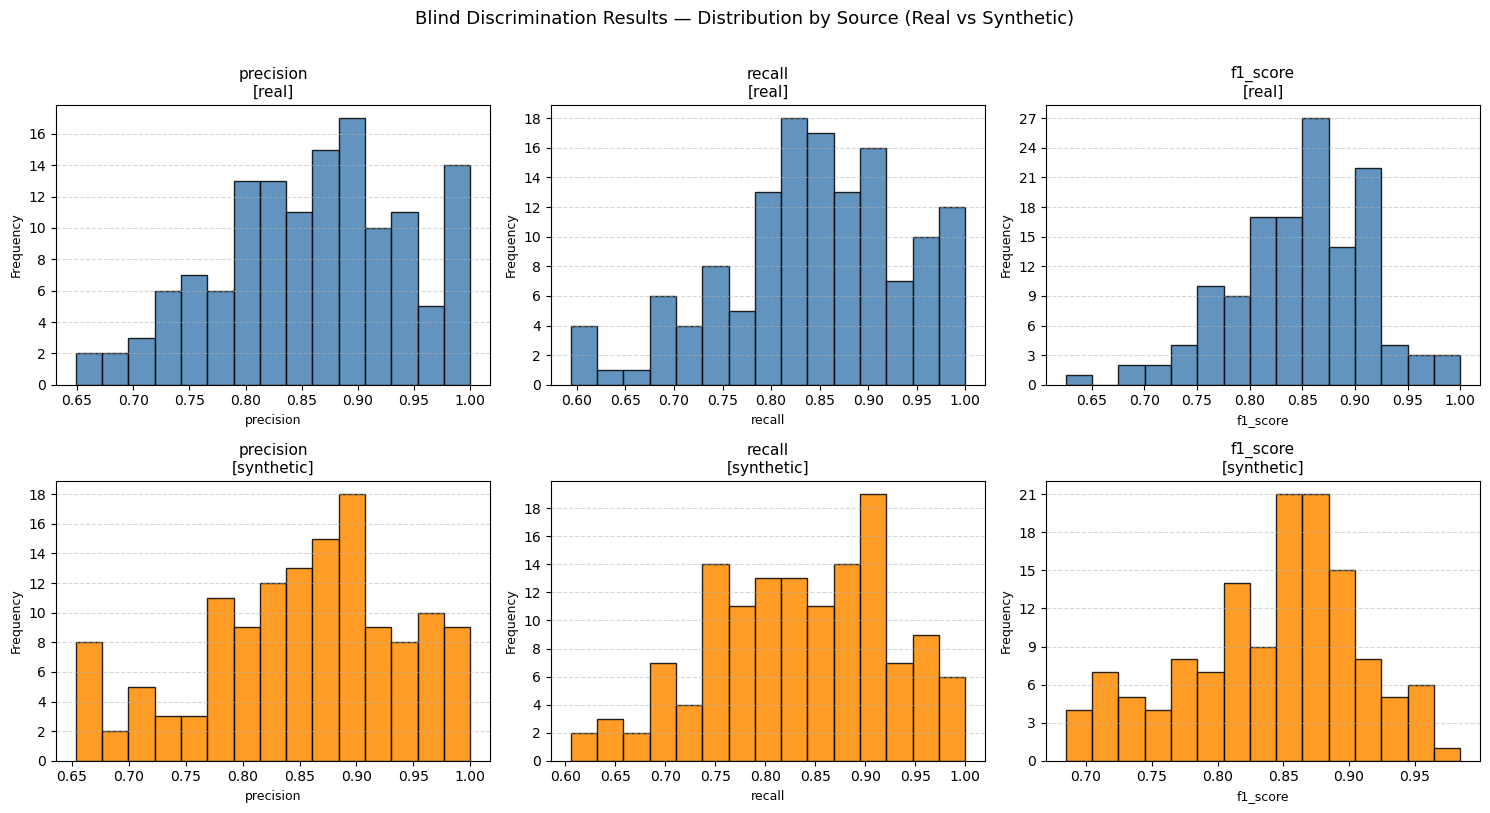

Histogram saved.


In [75]:
# Histogramas por tipo de imagem (real vs synthetic) — exclui 'control'

numeric_cols = ['precision', 'recall', 'f1_score']
sources = [s for s in df2['image_source_ground_truth'].unique() if s != 'control']
colors = {'real': 'steelblue', 'synthetic': 'darkorange'}

fig, axes = plt.subplots(len(sources), len(numeric_cols),
                         figsize=(5 * len(numeric_cols), 4 * len(sources)),
                         squeeze=False)

for row, source in enumerate(sources):
    subset = df2[df2['image_source_ground_truth'] == source]
    for col_idx, col in enumerate(numeric_cols):
        ax = axes[row][col_idx]
        ax.hist(subset[col].dropna(), bins=15,
                color=colors.get(source, 'gray'), edgecolor='black', alpha=0.85)
        ax.set_title(f'{col}\n[{source}]', fontsize=11)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Blind Discrimination Results — Distribution by Source (Real vs Synthetic)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('blind_discrimination_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram saved.")


Total de imagens de controle no dataset: 10
Especialistas: Expert_1, Expert_2, Expert_3

=== Contagem e Avaliação — Imagens de Controle ===
              Total controle  Corretos (∅)  Falso Positivo  Taxa FP (%)  Julgou: real  Julgou: synth  Julgou: ctrl
Especialista                                                                                                      
Expert_1                  10            10               0          0.0             0              0            10
Expert_2                  10            10               0          0.0             0              0            10
Expert_3                  10            10               0          0.0             0              0            10

=== Detalhe por Imagem de Controle ===
  Expert  Imagem         Arquivo  Marcou_sal Julgou_origem           notes
Expert_1 IMG_091 control_001.png           0       control control_no_salt
Expert_2 IMG_091 control_001.png           0       control control_no_salt
Expert_3 IMG_091 con

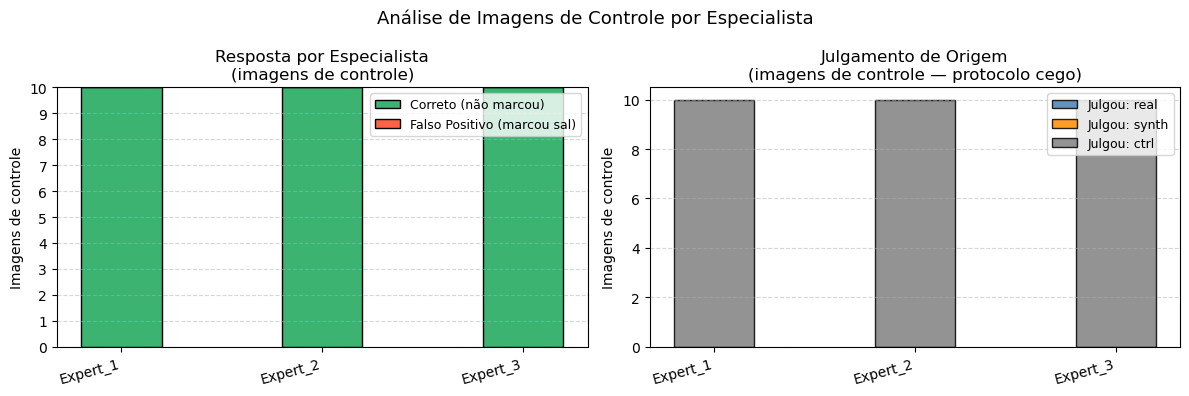

Gráfico salvo: control_analysis.png


In [66]:
# ── Análise de imagens de CONTROLE (sem sal) por Especialista ─────────────────
# Métrica relevante: especialista marcou sal? (segmentation_done=1 → falso positivo)
# predicted_source: julgamento cego de origem (real/synthetic) — válido pelo protocolo

df_ctrl = df[df['image_source_ground_truth'] == 'control'].copy()
experts = sorted(df_ctrl['evaluator_name'].unique())

print(f"Total de imagens de controle no dataset: {len(df_ctrl['image_id'].unique())}")
print(f"Especialistas: {', '.join(experts)}\n")

# ── Tabela resumo por especialista ────────────────────────────────────────────
rows = []
for expert in experts:
    eg = df_ctrl[df_ctrl['evaluator_name'] == expert]
    total       = len(eg)
    fp          = int(eg['segmentation_done'].sum())   # marcou sal onde não há
    correct     = total - fp
    taxa_fp     = fp / total if total > 0 else 0
    # julgamento de origem (predicted_source)
    pred_counts = eg['predicted_source'].value_counts().to_dict()
    rows.append({
        'Especialista'  : expert,
        'Total controle': total,
        'Corretos (∅)'  : correct,
        'Falso Positivo': fp,
        'Taxa FP (%)'   : round(taxa_fp * 100, 1),
        'Julgou: real'  : pred_counts.get('real', 0),
        'Julgou: synth' : pred_counts.get('synthetic', 0),
        'Julgou: ctrl'  : pred_counts.get('control', 0),
    })

summary = pd.DataFrame(rows).set_index('Especialista')
print("=== Contagem e Avaliação — Imagens de Controle ===")
print(summary.to_string())
print()

# ── Detalhe por imagem de controle ────────────────────────────────────────────
print("=== Detalhe por Imagem de Controle ===")
detail = (df_ctrl[['evaluator_name', 'image_id', 'image_filename',
                    'segmentation_done', 'predicted_source', 'notes']]
          .sort_values(['image_id', 'evaluator_name'])
          .rename(columns={'evaluator_name': 'Expert',
                            'image_id': 'Imagem',
                            'image_filename': 'Arquivo',
                            'segmentation_done': 'Marcou_sal',
                            'predicted_source': 'Julgou_origem'}))
print(detail.to_string(index=False))
print()

# ── Gráfico: Falsos Positivos e Julgamento de Origem por Especialista ─────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1 — Corretos vs Falsos Positivos
fp_vals  = [r['Falso Positivo'] for r in rows]
ok_vals  = [r['Corretos (∅)']   for r in rows]
x        = np.arange(len(experts))
width    = 0.4

ax1.bar(x, ok_vals,  width, label='Correto (não marcou)', color='mediumseagreen', edgecolor='black')
ax1.bar(x, fp_vals,  width, bottom=ok_vals, label='Falso Positivo (marcou sal)', color='tomato', edgecolor='black')
ax1.set_xticks(x); ax1.set_xticklabels(experts, rotation=15, ha='right')
ax1.set_ylabel('Imagens de controle')
ax1.set_title('Resposta por Especialista\n(imagens de controle)')
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Gráfico 2 — Julgamento de Origem (predicted_source)
pred_labels = ['Julgou: real', 'Julgou: synth', 'Julgou: ctrl']
pred_colors = ['steelblue', 'darkorange', 'gray']
bottoms = np.zeros(len(experts))
for label, color in zip(pred_labels, pred_colors):
    vals = np.array([r[label] for r in rows])
    ax2.bar(x, vals, width, bottom=bottoms, label=label, color=color, edgecolor='black', alpha=0.85)
    bottoms += vals
ax2.set_xticks(x); ax2.set_xticklabels(experts, rotation=15, ha='right')
ax2.set_ylabel('Imagens de controle')
ax2.set_title('Julgamento de Origem\n(imagens de controle — protocolo cego)')
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Análise de Imagens de Controle por Especialista', fontsize=13)
plt.tight_layout()
plt.savefig('control_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: control_analysis.png")


  ASSESSMENT: Origin Judgment (real vs synthetic) per Evaluator
  Control images excluded
Evaluator Ground Truth  Total  Correct  Errors  Accuracy (%)
 Expert_1         real     45       28      17          62.2
 Expert_1    synthetic     45       30      15          66.7
 Expert_2         real     45       30      15          66.7
 Expert_2    synthetic     45       31      14          68.9
 Expert_3         real     45       27      18          60.0
 Expert_3    synthetic     45       26      19          57.8

=== Overall Summary per Evaluator ===
                Total  Correct  Errors  Accuracy_pct
evaluator_name                                      
Expert_1           90       58      32          64.4
Expert_2           90       61      29          67.8
Expert_3           90       53      37          58.9



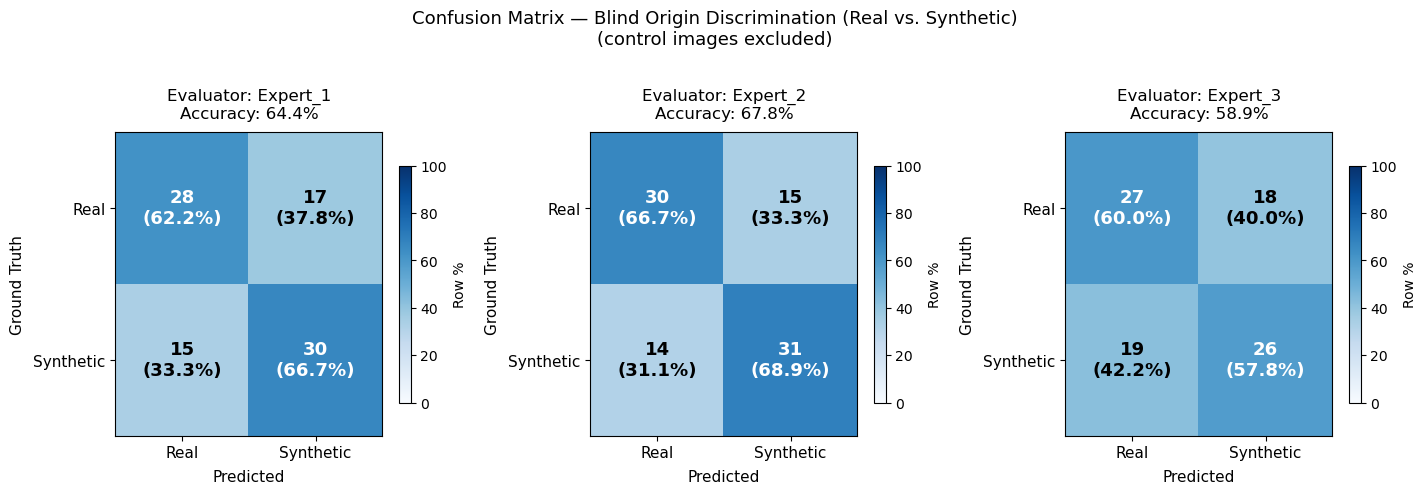

Figure saved: discrimination_confusion_matrix_per_evaluator.png


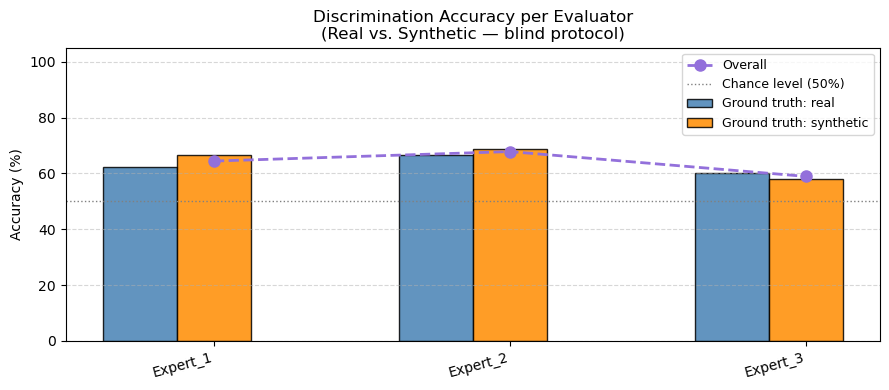

Figure saved: discrimination_accuracy.png


In [6]:

# ── Origin Judgment Assessment: Real vs. Synthetic per Evaluator ──────────────
# For non-control images, compares image_source_ground_truth vs predicted_source
# Metrics: accuracy, correct/errors, confusion matrix per evaluator

df = pd.read_csv('blind_discrimination_results.csv', sep=';')
df_eval = df[df['image_source_ground_truth'] != 'control'].copy()
df_eval['correct'] = (df_eval['image_source_ground_truth'] == df_eval['predicted_source']).astype(int)

experts = sorted(df_eval['evaluator_name'].unique())
sources = ['real', 'synthetic']
labels  = ['Real', 'Synthetic']   # display labels (title-case)

# ── Summary table per evaluator ───────────────────────────────────────────────
print("=" * 70)
print("  ASSESSMENT: Origin Judgment (real vs synthetic) per Evaluator")
print("  Control images excluded")
print("=" * 70)

rows_e = []
for expert in experts:
    eg = df_eval[df_eval['evaluator_name'] == expert]
    for src in sources:
        sub = eg[eg['image_source_ground_truth'] == src]
        c_src = int(sub['correct'].sum())
        rows_e.append({
            'Evaluator'   : expert,
            'Ground Truth': src,
            'Total'       : len(sub),
            'Correct'     : c_src,
            'Errors'      : len(sub) - c_src,
            'Accuracy (%)': round(c_src / len(sub) * 100, 1) if len(sub) else 0,
        })

detail_df = pd.DataFrame(rows_e)
print(detail_df.to_string(index=False))
print()

# Overall summary per evaluator
print("=== Overall Summary per Evaluator ===")
overall = (df_eval.groupby('evaluator_name')
           .agg(Total=('correct', 'count'), Correct=('correct', 'sum'))
           .assign(Errors=lambda x: x['Total'] - x['Correct'],
                   Accuracy_pct=lambda x: (x['Correct'] / x['Total'] * 100).round(1)))
print(overall.to_string())
print()

# ─────────────────────────────────────────────────────────────────────────────
# Helper: draw a 2×2 confusion matrix with counts + row-percentages
# ─────────────────────────────────────────────────────────────────────────────
def _draw_cm(ax, mat, title, cmap='Blues'):
    pct = mat / mat.sum(axis=1, keepdims=True) * 100
    im  = ax.imshow(pct, cmap=cmap, vmin=0, vmax=100, aspect='auto')
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11, labelpad=6)
    ax.set_ylabel('Ground Truth', fontsize=11, labelpad=6)
    ax.set_title(title, fontsize=12, pad=10)
    thresh = 50
    for i in range(2):
        for j in range(2):
            txt   = f'{int(mat[i, j])}\n({pct[i, j]:.1f}%)'
            color = 'white' if pct[i, j] > thresh else 'black'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=13, fontweight='bold', color=color)
    return im

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Per-evaluator confusion matrices only
# ─────────────────────────────────────────────────────────────────────────────
n_experts = len(experts)
fig, axes_cm = plt.subplots(1, n_experts,
                             figsize=(4.8 * n_experts, 4.8),
                             squeeze=False)

for col_i, expert in enumerate(experts):
    eg   = df_eval[df_eval['evaluator_name'] == expert]
    ax   = axes_cm[0][col_i]
    cm_e = (pd.crosstab(eg['image_source_ground_truth'],
                        eg['predicted_source'])
              .reindex(index=sources, columns=sources, fill_value=0))
    mat_e     = cm_e.values
    total_e   = mat_e.sum()
    correct_e = int(np.trace(mat_e))
    acc_e     = round(correct_e / total_e * 100, 1) if total_e else 0

    im = _draw_cm(ax, mat_e, title=f'Evaluator: {expert}\nAccuracy: {acc_e}%')
    fig.colorbar(im, ax=ax, shrink=0.78, label='Row %')

plt.suptitle(
    'Confusion Matrix — Blind Origin Discrimination (Real vs. Synthetic)\n'
    '(control images excluded)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('discrimination_confusion_matrix_per_evaluator.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: discrimination_confusion_matrix_per_evaluator.png")

# ── Accuracy bar chart per evaluator ─────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4))
x          = np.arange(n_experts)
width      = 0.25
colors_src = {'real': 'steelblue', 'synthetic': 'darkorange'}

for i, src in enumerate(sources):
    accs = [detail_df[(detail_df['Evaluator'] == e) &
                      (detail_df['Ground Truth'] == src)]['Accuracy (%)'].values[0]
            for e in experts]
    ax2.bar(x + (i - 1) * width, accs, width,
            label=f'Ground truth: {src}', color=colors_src[src],
            edgecolor='black', alpha=0.85)

overall_accs = [float(overall.loc[e, 'Accuracy_pct']) for e in experts]
ax2.plot(x, overall_accs, 'o--', color='mediumpurple', linewidth=2,
         markersize=8, label='Overall', zorder=5)

ax2.axhline(50, color='gray', linestyle=':', linewidth=1, label='Chance level (50%)')
ax2.set_xticks(x); ax2.set_xticklabels(experts, rotation=15, ha='right')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(0, 105)
ax2.set_title('Discrimination Accuracy per Evaluator\n'
              '(Real vs. Synthetic — blind protocol)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('discrimination_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: discrimination_accuracy.png")


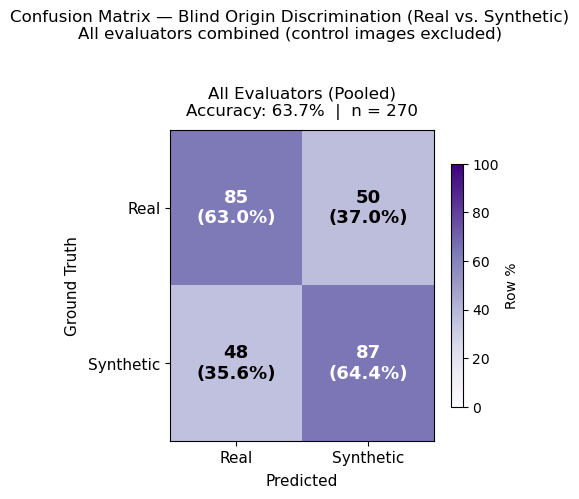

Figure saved: discrimination_confusion_matrix_pooled.png  (acc=63.7%, n=270)


In [7]:

# ── All Evaluators (Pooled) — Confusion Matrix ────────────────────────────────
# Aggregates all evaluators into a single 2×2 matrix for the paper summary figure

cm_pool  = (pd.crosstab(df_eval['image_source_ground_truth'],
                        df_eval['predicted_source'])
              .reindex(index=sources, columns=sources, fill_value=0))
mat_pool  = cm_pool.values
total_pool = mat_pool.sum()
acc_pool   = round(np.trace(mat_pool) / total_pool * 100, 1)

fig_pool, ax_pool = plt.subplots(figsize=(4.8, 4.8))

im_pool = _draw_cm(ax_pool, mat_pool,
                   title=f'All Evaluators (Pooled)\nAccuracy: {acc_pool}%  |  n = {total_pool}',
                   cmap='Purples')
fig_pool.colorbar(im_pool, ax=ax_pool, shrink=0.78, label='Row %')

plt.suptitle(
    'Confusion Matrix — Blind Origin Discrimination (Real vs. Synthetic)\n'
    'All evaluators combined (control images excluded)',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig('discrimination_confusion_matrix_pooled.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved: discrimination_confusion_matrix_pooled.png  (acc={acc_pool}%, n={total_pool})")


  ESTATÍSTICAS GERAIS — todos especialistas, todas imagens
  (excluindo controle)
  Total avaliações : 270
  Acertos          : 172  (63.7%)
  Erros            : 98  (36.3%)

  Detalhamento por tipo:
    real        : 85/135  (63.0% acurácia)
    synthetic   : 87/135  (64.4% acurácia)

  Matriz de Confusão (contagens):
Predito       real  synthetic
Ground Truth                 
real            85         50
synthetic       48         87

  Matriz de Confusão (% por linha — taxa por classe):
Predito       real  synthetic
Ground Truth                 
real          63.0       37.0
synthetic     35.6       64.4



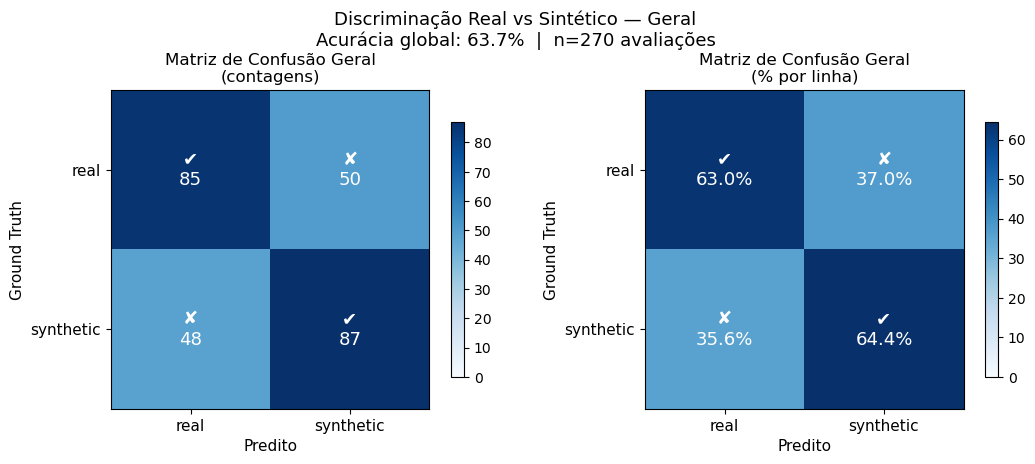

Gráfico salvo: discrimination_confusion_matrix_geral.png


In [40]:
# ── Estatísticas e Matriz de Confusão GERAL (todos os especialistas) ──────────
sources = ['real', 'synthetic']

df_all = df[df['image_source_ground_truth'] != 'control'].copy()
df_all['acerto'] = (df_all['image_source_ground_truth'] == df_all['predicted_source']).astype(int)

total_all   = len(df_all)
acertos_all = int(df_all['acerto'].sum())
erros_all   = total_all - acertos_all
acc_all     = round(acertos_all / total_all * 100, 1)

print("=" * 65)
print("  ESTATÍSTICAS GERAIS — todos especialistas, todas imagens")
print("  (excluindo controle)")
print("=" * 65)
print(f"  Total avaliações : {total_all}")
print(f"  Acertos          : {acertos_all}  ({acc_all}%)")
print(f"  Erros            : {erros_all}  ({round(100 - acc_all, 1)}%)")
print()

# Por tipo de ground truth
print("  Detalhamento por tipo:")
for src in sources:
    sub = df_all[df_all['image_source_ground_truth'] == src]
    ac  = int(sub['acerto'].sum())
    tot = len(sub)
    print(f"    {src:<12}: {ac}/{tot}  ({round(ac/tot*100,1)}% acurácia)")
print()

# Matriz de confusão geral (contagens e percentuais)
cm_all = pd.crosstab(
    df_all['image_source_ground_truth'],
    df_all['predicted_source'],
    rownames=['Ground Truth'],
    colnames=['Predito'],
).reindex(index=sources, columns=sources, fill_value=0)

print("  Matriz de Confusão (contagens):")
print(cm_all.to_string())
print()
print("  Matriz de Confusão (% por linha — taxa por classe):")
print((cm_all.div(cm_all.sum(axis=1), axis=0) * 100).round(1).to_string())
print()

# ── Figura: heatmap geral lado a lado (contagens + %) ────────────────────────
fig, (ax_n, ax_p) = plt.subplots(1, 2, figsize=(11, 4.5))
mat = cm_all.values

for ax, data, fmt, title_suffix in [
    (ax_n, mat,                                          'count', '(contagens)'),
    (ax_p, mat / mat.sum(axis=1, keepdims=True) * 100,  'pct',   '(% por linha)'),
]:
    vmax = data.max()
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=vmax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(sources, fontsize=11)
    ax.set_yticks([0, 1]); ax.set_yticklabels(sources, fontsize=11)
    ax.set_xlabel('Predito', fontsize=11)
    ax.set_ylabel('Ground Truth', fontsize=11)
    ax.set_title(f'Matriz de Confusão Geral\n{title_suffix}', fontsize=12)
    thresh = vmax / 2
    for i in range(2):
        for j in range(2):
            mark  = '✔' if i == j else '✘'
            val   = f'{data[i,j]:.1f}%' if fmt == 'pct' else str(int(data[i,j]))
            ax.text(j, i, f'{mark}\n{val}', ha='center', va='center', fontsize=13,
                    color='white' if data[i,j] > thresh else 'black')
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'Discriminação Real vs Sintético — Geral\n'
             f'Acurácia global: {acc_all}%  |  n={total_all} avaliações',
             fontsize=13)
plt.tight_layout()
plt.savefig('discrimination_confusion_matrix_geral.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: discrimination_confusion_matrix_geral.png")


  TESTE BINOMIAL — Discriminação acima do acaso?
  H0: p = 0.50  |  H1: p > 0.50  |  α = 0.05
  n (avaliações)   : 270
  k (acertos)      : 172
  p observado      : 0.6370  (63.7%)
  p-valor (exato)  : 0.000004
  IC 95% [low, –)  : [0.5861, 1.0)

  ✔ REJEITA H0  (p = 0.0000 < α = 0.05)
  → Os especialistas discriminam ACIMA do acaso (p > 0.50).
  → A acurácia de 63.7% é estatisticamente significativa.

  Detalhamento por tipo de imagem:
  Tipo             k     n    p_obs    p-valor  Conclusão
  -----------------------------------------------------------------
  real            85   135   0.6296   0.001640  ✔ sig.
  synthetic       87   135   0.6444   0.000500  ✔ sig.

  Nota: 'sig.' = significativo (p < 0.05), 'n.s.' = não significativo


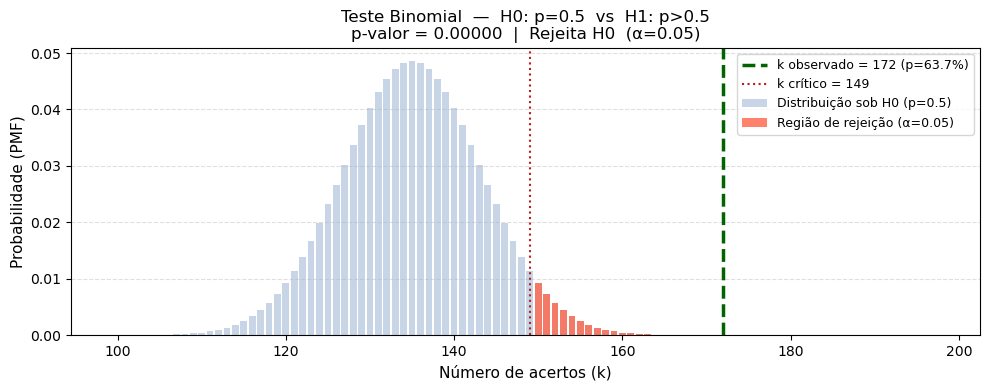

Gráfico salvo: binomial_test.png


In [41]:
# ── Teste Binomial: acurácia global é significativamente > 50% (acaso)? ────────
# H0: p = 0.5  (especialistas acertam apenas por acaso)
# H1: p > 0.5  (especialistas discriminam acima do acaso) — teste unilateral
# Referência: scipy.stats.binomtest (exato) + binom_test (alternativa normal)

from scipy import stats

n_total   = total_all    # 270 avaliações
k_acertos = acertos_all  # 172 acertos
p_acaso   = 0.5
alpha     = 0.05

# ── Teste exato de Binomial (scipy) ───────────────────────────────────────────
result = stats.binomtest(k_acertos, n=n_total, p=p_acaso, alternative='greater')
p_value   = result.pvalue
prop_obs  = k_acertos / n_total

# Intervalo de confiança 95% da proporção observada
ci = result.proportion_ci(confidence_level=0.95)

print("=" * 65)
print("  TESTE BINOMIAL — Discriminação acima do acaso?")
print("  H0: p = 0.50  |  H1: p > 0.50  |  α = 0.05")
print("=" * 65)
print(f"  n (avaliações)   : {n_total}")
print(f"  k (acertos)      : {k_acertos}")
print(f"  p observado      : {prop_obs:.4f}  ({round(prop_obs*100,1)}%)")
print(f"  p-valor (exato)  : {p_value:.6f}")
print(f"  IC 95% [low, –)  : [{ci.low:.4f}, 1.0)")
print()

if p_value < alpha:
    print(f"  ✔ REJEITA H0  (p = {p_value:.4f} < α = {alpha})")
    print(f"  → Os especialistas discriminam ACIMA do acaso (p > 0.50).")
    print(f"  → A acurácia de {round(prop_obs*100,1)}% é estatisticamente significativa.")
else:
    print(f"  ✘ NÃO rejeita H0  (p = {p_value:.4f} ≥ α = {alpha})")
    print(f"  → Sem evidência suficiente de discriminação acima do acaso.")

print()

# ── Teste por tipo de imagem (real / synthetic) ────────────────────────────────
print("  Detalhamento por tipo de imagem:")
print(f"  {'Tipo':<12} {'k':>5} {'n':>5} {'p_obs':>8} {'p-valor':>10}  Conclusão")
print(f"  {'-'*65}")
for src in ['real', 'synthetic']:
    sub    = df_all[df_all['image_source_ground_truth'] == src]
    k_src  = int(sub['acerto'].sum())
    n_src  = len(sub)
    r_src  = stats.binomtest(k_src, n=n_src, p=0.5, alternative='greater')
    sig    = '✔ sig.' if r_src.pvalue < alpha else '✘ n.s.'
    print(f"  {src:<12} {k_src:>5} {n_src:>5} {k_src/n_src:>8.4f} {r_src.pvalue:>10.6f}  {sig}")

print()
print("  Nota: 'sig.' = significativo (p < 0.05), 'n.s.' = não significativo")

# ── Visualização: distribuição binomial sob H0 vs valor observado ─────────────
from scipy.stats import binom

fig, ax = plt.subplots(figsize=(10, 4))
ks = np.arange(0, n_total + 1)
pmf = binom.pmf(ks, n_total, p_acaso)

# Região de rejeição (cauda direita, α = 0.05)
k_crit = int(binom.ppf(1 - alpha, n_total, p_acaso))

ax.bar(ks, pmf, color='lightsteelblue', edgecolor='none', alpha=0.7, label='Distribuição sob H0 (p=0.5)')
ax.bar(ks[ks > k_crit], pmf[ks > k_crit], color='tomato', alpha=0.8, label=f'Região de rejeição (α={alpha})')
ax.axvline(k_acertos, color='darkgreen', linewidth=2.5, linestyle='--',
           label=f'k observado = {k_acertos} (p={round(prop_obs*100,1)}%)')
ax.axvline(k_crit, color='firebrick', linewidth=1.5, linestyle=':',
           label=f'k crítico = {k_crit}')

ax.set_xlabel('Número de acertos (k)', fontsize=11)
ax.set_ylabel('Probabilidade (PMF)', fontsize=11)
ax.set_xlim(n_total * 0.35, n_total * 0.75)
ax.set_title(f'Teste Binomial  —  H0: p=0.5  vs  H1: p>0.5\n'
             f'p-valor = {p_value:.5f}  |  {"Rejeita H0" if p_value < alpha else "Não rejeita H0"}  (α={alpha})',
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('binomial_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: binomial_test.png")
